<a href="https://colab.research.google.com/github/tanu100/DeepLearning/blob/main/GradientDescent/BatchGradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
X,y=make_regression(n_samples=100,noise=20, n_features=2,random_state=42)

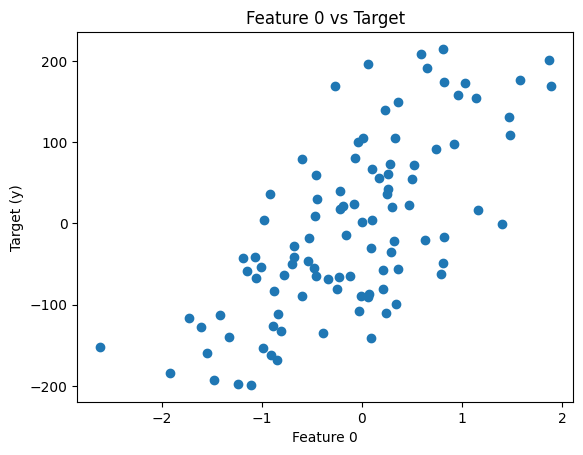

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], y)
plt.xlabel("Feature 0")
plt.ylabel("Target (y)")
plt.title("Feature 0 vs Target")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train,x_test,Y_train,y_test=train_test_split(X,y,random_state=42)

In [ ]:
print(len(X))
res=np.ones(X.shape[1])
print(X.ravel().shape)

100
(200,)


In [ ]:
class BatchGD:
  def __init__(self,rate,epoch):
    self.intercept=0.0
    self.coff=0.0
    self.rate=rate
    self.epoch=epoch

  def _fit_(self,X,y):
    self.coff=np.zeros(X.shape[1]) # coff=1 cuz feature is 1 x.shape ->(100,1) 100 rows for 1 feature!!
    self.intercept=0.0
    for _ in range(self.epoch):
        y_hat=self.intercept + (X@self.coff)
        db=-2 * (np.mean(y-y_hat))
        dw= -2*((y-y_hat)@X) /X.shape[0]
        self.intercept= self.intercept - (self.rate * (db))
        self.coff= self.coff - (self.rate * dw)
    print(self.intercept)
    print(self.coff)

  def _predict_(self,x_test):
    return self.intercept + (x_test@self.coff)

In [ ]:
lr=LinearRegression()
lr.fit(X_train,Y_train)
print(lr.intercept_)
print(lr.coef_)
arr1=lr.predict(x_test)
print(arr1)

-0.8717887315951369
[85.16595642 73.35458972]
[ -56.68380648   -1.05575443   83.75639842  -21.87736378   65.36505276
  111.45443624  189.91824078 -126.83451882 -182.84111104  -54.16906987
   78.45046947 -138.8541967   114.38497459  -41.74986987  110.85084581
   74.59107379  -26.1452172    -0.21054005  -73.42283256   42.14212875
  -71.33808359   15.60178701  -17.64433923  -77.06050942  -91.20299488]


In [ ]:
obj=BatchGD(0.01,1000)
obj._fit_(X_train,Y_train)
arr2=obj._predict_(x_test)
print(arr2)

-0.8717988740872002
[85.16593469 73.35459512]
[ -56.68379075   -1.05575144   83.75641135  -21.87739824   65.36503288
  111.4544074   189.91820047 -126.83454408 -182.8411036   -54.16905058
   78.45046244 -138.85421957  114.38496656  -41.74986398  110.85084489
   74.59104853  -26.14520192   -0.21057228  -73.42283123   42.14211693
  -71.3380667    15.60177087  -17.64435075  -77.0605183   -91.20298974]


In [ ]:
np.array_equal(arr1,arr2)

False